    # 04 — EDA on the Corrected First-Transaction Data

## What this data is — two restrictions, not one

The table explored here has been narrowed twice, and both restrictions have to be held in mind when reading any number in this notebook.

**1. First transactions only.** Every customer contributes exactly one invoice — their *earliest*. Later purchases are not in this table at all. This is not a sample of the retailer's business; it is the single opening purchase of each customer, which is all a model gets to see when predicting churn from the first transaction.

**2. Corrected.** Every data-quality fix from `02_data_quality_first_txn.ipynb` has been applied by `src/correct_data_issues.py` and validated in `03_data_correction_checks.ipynb`.

**Source:** `data/processed/first_transaction_churn_clean.csv` — 125,042 line items, 5,044 customers.

## Why the first restriction matters more than it looks

`01_eda_raw` explored the full file: 1,067,371 rows, 53,628 invoices, 5,942 customers, averaging 7.55 invoices and 138.7 line items each. **None of those figures apply here.** This table holds one invoice per customer, a median of 18 line items — so anything from `01` about customer totals, repeat behaviour, retention curves or inter-purchase gaps describes a different population and must not be carried across.

Concretely, `01` never asked how many products a customer bought *in their first transaction*, how much they spent on it, or how any of that relates to `churn`. Its §9 aggregates all 53,628 invoices including cancellations; its §11 aggregates each customer's whole history. Those are the questions this notebook opens up.

## What was corrected, and what was left alone

**Applied:** cancellations removed, zero prices removed, non-product stock codes removed (`POST`, `M`, `D`, `ADJUST`, `PADS`, `DOT`, `BANK CHARGES`), test products removed, descriptions made consistent per `stock_code`.

**Deliberately left in place:** outliers (the model is tree-based), and descriptions mapping to more than one `stock_code` (`stock_code` is the source of truth for product identity).

So distributions here are already free of the known defects — a long tail in `quantity` or `price` is real purchasing behaviour, not dirt.

## Grain — read this before interpreting anything

The table is **one row per line item**: 125,042 rows across 5,044 customers, a median of 18 rows each. Each customer contributes exactly one invoice (their first), split across as many rows as it had products.

This matters for every statistic in the notebook:

- `churn` is a **per-customer** label repeated across all of that customer's rows. A row-level churn rate (41.4% of rows) is *not* the churn rate (45.6% of customers) — customers with larger baskets contribute more rows and get weighted more heavily.
- The same applies to `country`, `invoice`, `invoice_date` and `customer_id`, which are all constant within a customer.
- Only `stock_code`, `description`, `quantity`, `price` and `line_total` genuinely vary row to row.

So: aggregate to the customer before saying anything about customers, and be explicit about which grain a chart is drawn at.

## Variables

All 10 columns survive the corrections — no column was dropped, only rows.

| Variable | Type | Varies by | Description |
|---|---|---|---|
| `invoice` | int64 | customer | Invoice number of the customer's first transaction. 5,044 unique — one per customer. Now integer rather than string, because removing cancellations eliminated every `C`-prefixed value. |
| `stock_code` | object | line | Product identifier, 4,171 unique. Treated as the **source of truth** for product identity. Non-product codes (`POST`, `M`, `D`, `ADJUST`, `PADS`, `DOT`, `BANK CHARGES`) and `TEST*` placeholders have been removed. |
| `description` | object | line | Product name, 4,152 unique. Normalised so each `stock_code` carries a single description. Fewer distinct descriptions than stock codes because some genuinely different products share a label (issue 4, left uncorrected on purpose). |
| `quantity` | int64 | line | Units of that product on the line. Range 1 → 7,128, median 4. All positive: negatives only occurred on cancellations, which are gone. |
| `invoice_date` | datetime64 | customer | Timestamp of the first transaction, 2009-12-01 → 2011-09-09. Constant within a customer up to a few seconds. Carries hour-of-day, weekday and month signal that is not yet extracted. |
| `price` | float64 | line | Unit price in GBP. Range 0.03 → 295.00, median 1.95. Zero prices removed. |
| `customer_id` | int64 | customer | Customer key, 5,044 unique. An identifier, **not** a feature — do not feed it to a model. |
| `country` | object | customer | Customer country, 40 distinct values but 91% United Kingdom, with a long thin tail (Germany 87 customers, France 70, Spain 29). Needs grouping or encoding before use. |
| `line_total` | float64 | line | `quantity × price`. Range 0.06 → 6,539.40, median 11.25. Fully determined by the two columns above — collinear by construction. |
| `churn` | int64 | customer | **Target.** 1 if the customer made no second purchase within 90 days of the first, or made it later than 90 days; 0 if they returned within 90 days. 45.6% of customers churn. |

No missing values in any column.

**Two caveats carried forward from earlier notebooks**, both of which affect how these variables should be read:

1. The `churn` label counts cancellation invoices as qualifying second purchases, so 823 customers (28% of the retained class) are labelled *retained* on the strength of a cancellation. Under review — see `03`.
2. Customers whose first purchase falls in the dataset's opening month (889 customers, 17.6%) may be established customers whose earlier history predates the file. Their churn rate is 33.3% against 48.3% for everyone else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Single accent hue for one-series charts; ORANGE only where a second series exists.
BLUE, ORANGE, MUTED = '#2a78d6', '#eb6834', '#52514e'


def style_axis(ax):
    """Recessive grid and spines so the data reads first."""
    ax.grid(axis='y', color='0.9', lw=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.7')
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    return ax


PROCESSED = Path('..') / 'data' / 'processed'
clean = pd.read_csv(PROCESSED / 'first_transaction_churn_clean.csv', parse_dates=['invoice_date'])

n_rows, n_cust = len(clean), clean['customer_id'].nunique()
n_inv = clean['invoice'].nunique()
churn_rate = clean.drop_duplicates('customer_id')['churn'].mean()

print('Corrected FIRST-TRANSACTION data — one invoice per customer, later purchases excluded')
print(f'  Rows (line items) : {n_rows:,}')
print(f'  Customers         : {n_cust:,}')
print(f'  Invoices          : {n_inv:,}   (== customers: {n_inv == n_cust})')
print(f'  Line items each   : median {clean.groupby("customer_id").size().median():.0f}')
print(f'  Churn rate        : {churn_rate:.2%}  (per customer, not per row)')
clean.head()

Corrected FIRST-TRANSACTION data — one invoice per customer, later purchases excluded
  Rows (line items) : 125,042
  Customers         : 5,044
  Invoices          : 5,044   (== customers: True)
  Line items each   : median 18
  Churn rate        : 45.64%  (per customer, not per row)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,line_total,churn
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,0


## 1. One invoice per customer

The defining property of this table. `prepare_churn_data.py` keeps only each customer's earliest invoice, so `customer_id` and `invoice` should be in strict one-to-one correspondence. If this check ever fails, the first-transaction filter has broken and nothing else in the notebook can be trusted.

Checked in both directions: no customer has more than one invoice, and no invoice is shared by more than one customer.

In [2]:
invoices_per_customer = clean.groupby('customer_id')['invoice'].nunique()
customers_per_invoice = clean.groupby('invoice')['customer_id'].nunique()

print('customer_id -> invoice')
print(f'  customers                    : {len(invoices_per_customer):,}')
print(f'  with exactly 1 invoice       : {(invoices_per_customer == 1).sum():,}')
print(f'  with more than 1 invoice     : {(invoices_per_customer > 1).sum():,}')
print()
print('invoice -> customer_id')
print(f'  invoices                     : {len(customers_per_invoice):,}')
print(f'  with exactly 1 customer      : {(customers_per_invoice == 1).sum():,}')
print(f'  with more than 1 customer    : {(customers_per_invoice > 1).sum():,}')
print()

one_to_one = (invoices_per_customer == 1).all() and (customers_per_invoice == 1).all()
print(f'Strict 1:1 between customer_id and invoice : {one_to_one}')

# Same invoice timestamp throughout a customer's lines (a single invoice spans seconds, not days).
spread = (clean.groupby('customer_id')['invoice_date'].max()
          - clean.groupby('customer_id')['invoice_date'].min()).dt.total_seconds()
print(f'Max timestamp spread within a customer     : {spread.max():.0f} seconds')

customer_id -> invoice
  customers                    : 5,044
  with exactly 1 invoice       : 5,044
  with more than 1 invoice     : 0

invoice -> customer_id
  invoices                     : 5,044
  with exactly 1 customer      : 5,044
  with more than 1 customer    : 0

Strict 1:1 between customer_id and invoice : True
Max timestamp spread within a customer     : 120 seconds


## 2. Products per first transaction

How many distinct `stock_code`s each customer bought in their opening purchase — basket breadth, and one of the few things a model knows about a customer at prediction time.

Not answered in `01`: its §9 counts `n_unique_products` per invoice across all 53,628 invoices including cancellations, and its §11 aggregates each customer's entire history. Neither is this quantity.

Also worth separating from **line count**: a product appearing on two lines of the same invoice makes `n_lines > n_distinct_products`. Both are shown.

Distinct products in the first transaction:
count   5,044.00
mean       23.74
std        22.27
min         1.00
25%         9.00
50%        18.00
75%        31.00
90%        50.00
99%       110.00
max       250.00

Customers buying a single product : 184 (3.65%)
Repeat lines for the same product : 1,012 customers (20.06%)


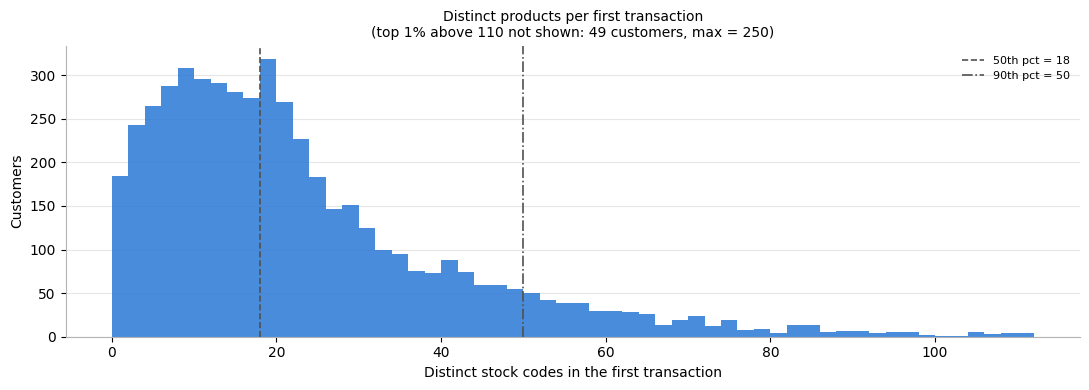

In [3]:
by_customer = clean.groupby('customer_id')
n_products = by_customer['stock_code'].nunique()
n_lines = by_customer.size()

print('Distinct products in the first transaction:')
print(n_products.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2).to_string())
print()
print(f'Customers buying a single product : {(n_products == 1).sum():,} '
      f'({(n_products == 1).mean()*100:.2f}%)')
print(f'Repeat lines for the same product : {(n_lines > n_products).sum():,} customers '
      f'({(n_lines > n_products).mean()*100:.2f}%)')

# Trim the top 1% rather than clipping it: clipping stacks every extreme value into
# the final bin, producing a spike that reads as a real mode. Bin edges are placed on
# even integers because the variable is a count — fractional widths would make some
# bins cover two integers and others one, giving a false comb pattern.
cut = n_products.quantile(0.99)
shown = n_products[n_products <= cut]
hidden = len(n_products) - len(shown)

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(shown, bins=np.arange(0, cut + 3, 2), color=BLUE, alpha=0.85)
for p, ls in [(0.5, '--'), (0.9, '-.')]:
    v = n_products.quantile(p)
    ax.axvline(v, color=MUTED, ls=ls, lw=1.2, label=f'{int(p*100)}th pct = {v:,.0f}')
ax.set_title(f'Distinct products per first transaction\n'
             f'(top 1% above {cut:,.0f} not shown: {hidden} customers, max = {n_products.max():,})',
             fontsize=10)
ax.set_xlabel('Distinct stock codes in the first transaction')
ax.set_ylabel('Customers')
ax.legend(fontsize=8, frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

## 3. Quantity and price per customer

Drawn at **customer grain**, one point per customer — matching the modelling table in `src/build_features.py` rather than the line-item view.

- **`total_quantity`** — units bought across the whole first transaction.
- **`avg_unit_price`** — unweighted mean of the line prices. The quantity-weighted alternative is `total_spend / total_quantity`; the two differ whenever a customer buys many cheap units and few expensive ones.

`01` §6 plots `quantity` and `price` too, but at line-item grain on the raw file, including cancellations and zero prices. These are different distributions of different quantities over a different population.

Both are heavily right-skewed and shown clipped at the 99th percentile so the bulk is legible; the true maxima are in the titles. Those extremes are **real purchasing behaviour, not dirt** — issue 7 was deliberately left uncorrected because the model is tree-based.

Customer-level distributions (n = 5,044):
       total_quantity  avg_unit_price  total_spend
count        5,044.00        5,044.00     5,044.00
mean           262.60            3.56       407.30
std          1,322.09            6.35       736.71
min              1.00            0.15         1.30
25%             81.00            2.09       167.39
50%            153.00            2.88       293.25
75%            280.00            3.87       447.13
90%            483.40            5.25       756.04
99%          1,567.37           13.14     2,320.13
max         87,167.00          295.00    33,167.80


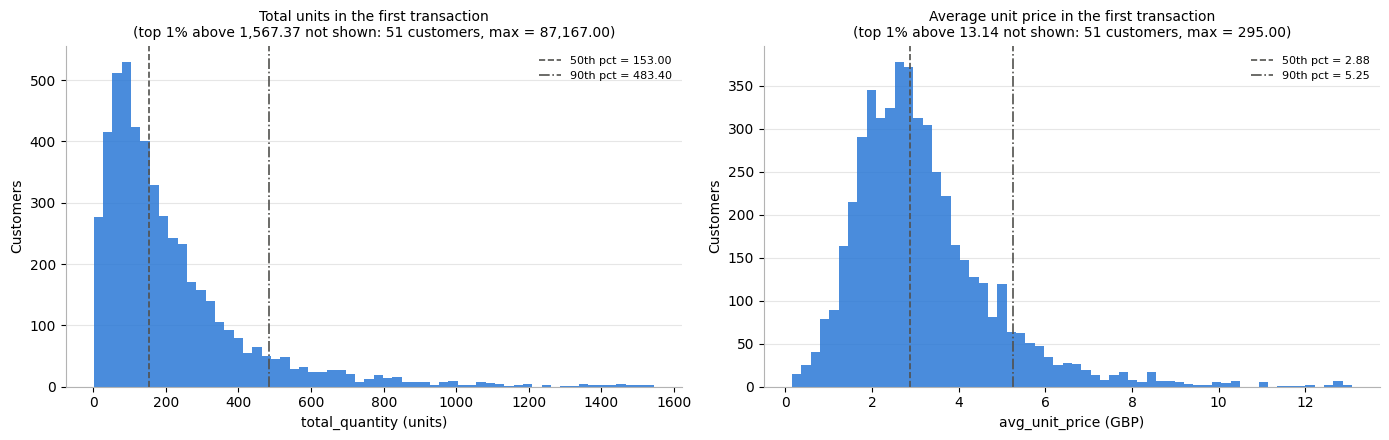


Unweighted vs quantity-weighted average price:
  median unweighted : 2.88 GBP
  median weighted   : 1.88 GBP
  correlation       : 0.940


In [4]:
per_customer = pd.DataFrame({
    'total_quantity': by_customer['quantity'].sum(),
    'avg_unit_price': by_customer['price'].mean(),
    'total_spend': by_customer['line_total'].sum(),
})

print('Customer-level distributions (n = {:,}):'.format(len(per_customer)))
print(per_customer.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2).to_string())

specs = [
    ('total_quantity', 'Total units in the first transaction', 'units'),
    ('avg_unit_price', 'Average unit price in the first transaction', 'GBP'),
]

# Trim the top 1% rather than clipping it — see the note in the previous cell.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (col, title, unit) in zip(axes, specs):
    s = per_customer[col]
    cut = s.quantile(0.99)
    shown = s[s <= cut]
    hidden = len(s) - len(shown)
    ax.hist(shown, bins=60, color=BLUE, alpha=0.85)
    for p, ls in [(0.5, '--'), (0.9, '-.')]:
        v = s.quantile(p)
        ax.axvline(v, color=MUTED, ls=ls, lw=1.2, label=f'{int(p*100)}th pct = {v:,.2f}')
    ax.set_title(f'{title}\n(top 1% above {cut:,.2f} not shown: {hidden} customers, '
                 f'max = {s.max():,.2f})', fontsize=10)
    ax.set_xlabel(f'{col} ({unit})')
    ax.set_ylabel('Customers')
    ax.legend(fontsize=8, frameon=False)
    style_axis(ax)

plt.tight_layout()
plt.show()

# How far the two price definitions diverge.
weighted = per_customer['total_spend'] / per_customer['total_quantity']
print(f'\nUnweighted vs quantity-weighted average price:')
print(f'  median unweighted : {per_customer["avg_unit_price"].median():.2f} GBP')
print(f'  median weighted   : {weighted.median():.2f} GBP')
print(f'  correlation       : {per_customer["avg_unit_price"].corr(weighted):.3f}')

### 3a. Churned vs retained: price and quantity

The same two variables as §3, split by the target. This is the first place in the notebook where a feature meets `churn`.

- **`avg_unit_price`** — per-customer mean of the line prices.
- **`total_quantity`** — total units in the first transaction.

**Log y-axis, every point kept.** Both variables span four to five orders of magnitude (quantity runs 1 → 87,167), so on a linear scale the boxes collapse to slivers against the extreme fliers. Log scale keeps the boxes legible without discarding anything — but distances are multiplicative, so read the *ratio* between medians rather than the visual gap.

Boxes are Tukey: the box spans the interquartile range, the line inside is the median, whiskers reach 1.5×IQR, and points beyond are drawn individually. Medians and a Mann-Whitney test are printed underneath, since a visual difference at this sample size still needs a number attached.

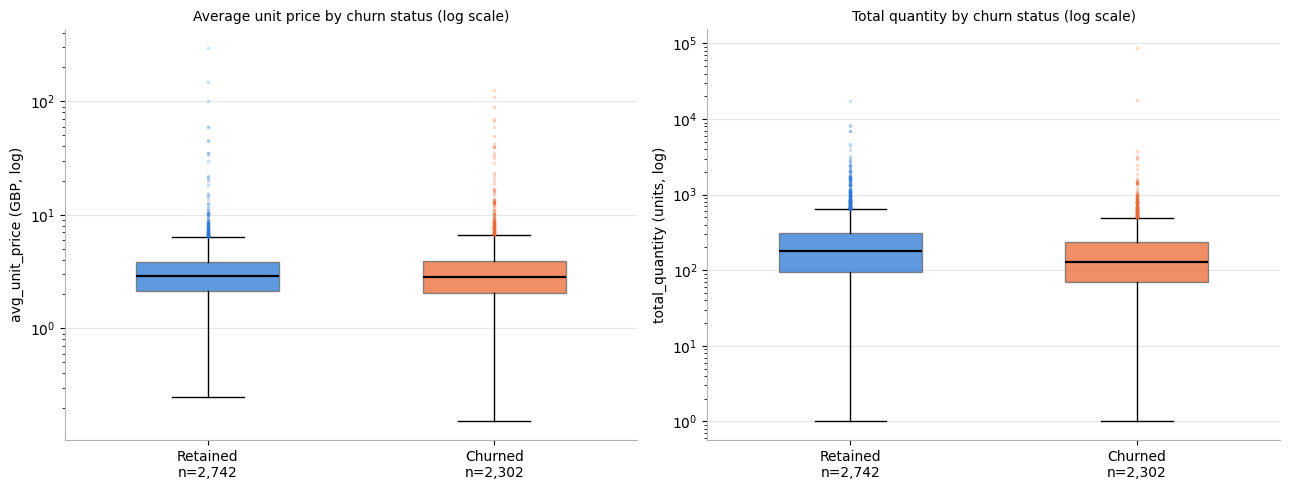

Average unit price (GBP):
  retained median       2.92   churned median       2.83   ratio 1.03x
  Mann-Whitney U p-value: 0.188
Total quantity (units):
  retained median     178.00   churned median     127.00   ratio 1.40x
  Mann-Whitney U p-value: 5.72e-32


In [5]:
from scipy.stats import mannwhitneyu

per_customer['churn'] = by_customer['churn'].first()

box_specs = [
    ('avg_unit_price', 'Average unit price', 'GBP'),
    ('total_quantity', 'Total quantity', 'units'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, title, unit) in zip(axes, box_specs):
    retained = per_customer.loc[per_customer['churn'] == 0, col]
    churned = per_customer.loc[per_customer['churn'] == 1, col]

    bp = ax.boxplot([retained, churned], whis=1.5, showfliers=True, widths=0.5,
                    patch_artist=True, medianprops=dict(color='black', lw=1.6),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.25,
                                    markeredgecolor='none'))
    for patch, colour in zip(bp['boxes'], [BLUE, ORANGE]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.75)
        patch.set_edgecolor('0.4')
    for flier, colour in zip(bp['fliers'], [BLUE, ORANGE]):
        flier.set_markerfacecolor(colour)

    ax.set_yscale('log')
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Retained\nn={len(retained):,}', f'Churned\nn={len(churned):,}'])
    ax.set_title(f'{title} by churn status (log scale)', fontsize=10)
    ax.set_ylabel(f'{col} ({unit}, log)')
    ax.grid(axis='y', color='0.9', lw=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.7')

plt.tight_layout()
plt.show()

for col, title, unit in box_specs:
    retained = per_customer.loc[per_customer['churn'] == 0, col]
    churned = per_customer.loc[per_customer['churn'] == 1, col]
    stat, p = mannwhitneyu(retained, churned, alternative='two-sided')
    print(f'{title} ({unit}):')
    print(f'  retained median {retained.median():>10,.2f}   churned median {churned.median():>10,.2f}'
          f'   ratio {retained.median() / churned.median():.2f}x')
    print(f'  Mann-Whitney U p-value: {p:.3g}')

## 4. Churn rate by time of first purchase

`invoice_date` carries weekday, hour and month, none of them extracted as features yet. §4a and §4b test whether weekday or hour is worth extracting; §6 covers month.

### 4a. By weekday

**Read the sample sizes before the rates.** Saturday has only 25 first transactions against 687–1,030 on other days: the retailer barely trades on Saturdays. A rate on 25 customers shifts 4 points when a single customer flips, so Saturday's bar carries almost no information wherever it lands. Every bar is labelled with its `n`, and the dashed line marks the overall 45.6% churn rate so deviations are read against the base rate rather than against each other.

Churn rate by weekday of first purchase:
     customers  churn_rate
Mon        758       49.47
Tue        914       42.67
Wed        916       47.60
Thu       1030       44.66
Fri        687       44.10
Sat         25       24.00
Sun        714       46.50

Overall churn rate: 45.64%
Spread excluding Saturday (n=25): 6.8%


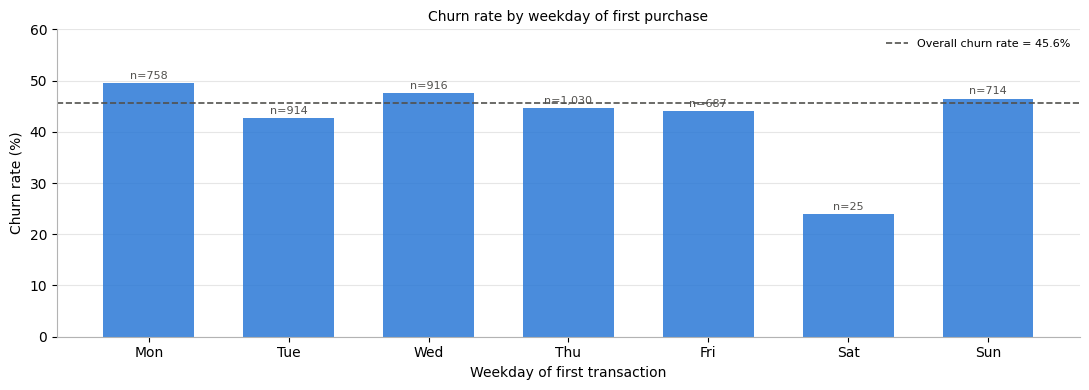

In [6]:
DAY_NAMES = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

customers = pd.DataFrame({
    'churn': by_customer['churn'].first(),
    'first_date': by_customer['invoice_date'].min(),
    'country': by_customer['country'].first(),
    'total_spend': by_customer['line_total'].sum(),
})
customers['weekday'] = customers['first_date'].dt.dayofweek

weekday = (customers.groupby('weekday')['churn']
           .agg(customers='size', churn_rate='mean')
           .reindex(range(7)))
weekday.index = DAY_NAMES

print('Churn rate by weekday of first purchase:')
print(weekday.assign(churn_rate=lambda d: (d['churn_rate'] * 100).round(2)).to_string())
print(f'\nOverall churn rate: {churn_rate:.2%}')
print(f'Spread excluding Saturday (n=25): '
      f'{weekday.drop("Sat")["churn_rate"].max() - weekday.drop("Sat")["churn_rate"].min():.1%}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(weekday.index, weekday['churn_rate'] * 100, color=BLUE, alpha=0.85, width=0.65)
ax.axhline(churn_rate * 100, color=MUTED, ls='--', lw=1.2,
           label=f'Overall churn rate = {churn_rate:.1%}')
for day, row in weekday.iterrows():
    ax.text(day, row['churn_rate'] * 100 + 0.8, f'n={int(row["customers"]):,}',
            ha='center', fontsize=8, color=MUTED)
ax.set_title('Churn rate by weekday of first purchase', fontsize=10)
ax.set_xlabel('Weekday of first transaction')
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 60)
ax.legend(fontsize=8, frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

### 4b. By hour of day

All **24 hours** on the x-axis, as requested — including the ones with no trade at all.

That is deliberate rather than wasteful: the retailer only transacts between roughly 07:00 and 20:00, so the empty bars at either end are themselves the finding. A model given raw `hour` as a numeric feature would treat 23 and 0 as far apart when both are simply closed, which is an argument for a cyclical encoding or a business-hours bucket rather than the raw integer.

Bars are labelled with `n` and the dashed line is the overall churn rate. Hours at the edges of trading carry very few customers, so as with weekday, check the count before reading anything into the height.

Churn rate by hour of first purchase (all 24 hours):
      customers  churn_rate
hour                       
0             0         NaN
1             0         NaN
2             0         NaN
3             0         NaN
4             0         NaN
5             0         NaN
6             0         NaN
7            13       46.15
8           133       44.36
9           341       42.23
10          508       46.06
11          612       46.57
12          802       45.89
13          819       45.54
14          646       45.20
15          567       48.15
16          319       47.65
17          167       44.31
18           54       40.74
19           49       34.69
20           14       21.43
21            0         NaN
22            0         NaN
23            0         NaN

Hours with any first transaction : 14 of 24 (07:00 to 20:00)
Hours with no trade              : 10
Hours with n >= 100              : 10
  their churn range              : 42.2% to 48.1% (spread 5.9%)
Busiest hour     

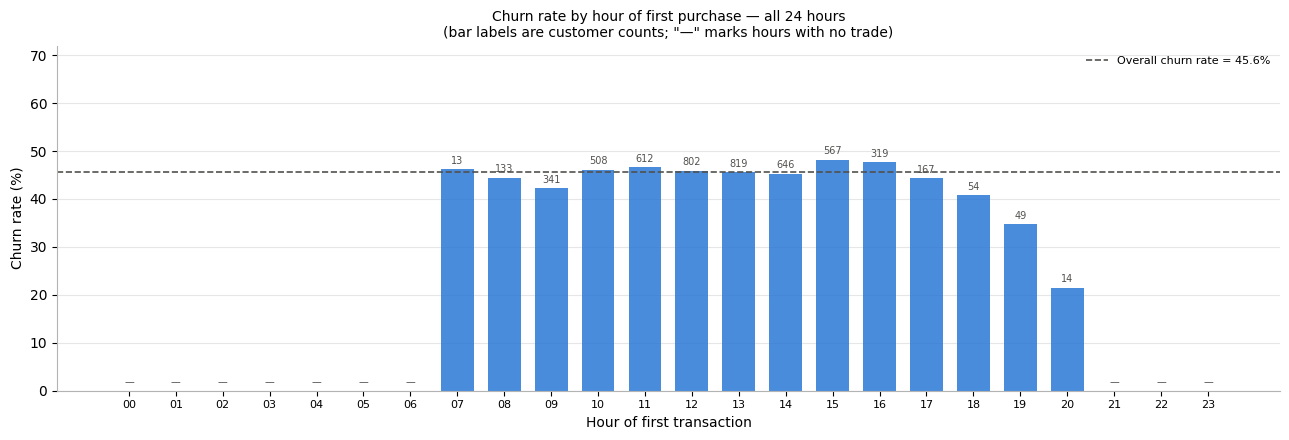

In [7]:
customers['hour'] = customers['first_date'].dt.hour

# Reindex over all 24 hours so closed hours appear as empty bars rather than vanishing.
hourly = (customers.groupby('hour')['churn']
          .agg(customers='size', churn_rate='mean')
          .reindex(range(24)))

print('Churn rate by hour of first purchase (all 24 hours):')
print(hourly.assign(customers=lambda d: d['customers'].fillna(0).astype(int),
                    churn_rate=lambda d: (d['churn_rate'] * 100).round(2)).to_string())

traded = hourly.dropna(subset=['churn_rate'])
print(f'\nHours with any first transaction : {len(traded)} of 24 '
      f'({traded.index.min():02d}:00 to {traded.index.max():02d}:00)')
print(f'Hours with no trade              : {24 - len(traded)}')

solid = hourly[hourly['customers'].fillna(0) >= 100]
print(f'Hours with n >= 100              : {len(solid)}')
print(f'  their churn range              : {solid["churn_rate"].min():.1%} to '
      f'{solid["churn_rate"].max():.1%} '
      f'(spread {solid["churn_rate"].max() - solid["churn_rate"].min():.1%})')
print(f'Busiest hour                     : {int(hourly["customers"].idxmax()):02d}:00 '
      f'({int(hourly["customers"].max()):,} customers)')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(hourly.index, hourly['churn_rate'].fillna(0) * 100, color=BLUE, alpha=0.85, width=0.7)
ax.axhline(churn_rate * 100, color=MUTED, ls='--', lw=1.2,
           label=f'Overall churn rate = {churn_rate:.1%}')
for hour, row in hourly.iterrows():
    n = 0 if pd.isna(row['customers']) else int(row['customers'])
    height = 0 if pd.isna(row['churn_rate']) else row['churn_rate'] * 100
    ax.text(hour, height + 1.2, f'{n:,}' if n else '—',
            ha='center', fontsize=7, color=MUTED, rotation=90 if n >= 1000 else 0)
ax.set_title('Churn rate by hour of first purchase — all 24 hours\n'
             '(bar labels are customer counts; "—" marks hours with no trade)', fontsize=10)
ax.set_xlabel('Hour of first transaction')
ax.set_ylabel('Churn rate (%)')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=8)
ax.set_ylim(0, 72)
ax.legend(fontsize=8, frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

## 5. First transactions over time (daily)

Because every row belongs to a customer's *first* invoice, counting transactions per day is really a **customer-acquisition curve**: how many new customers the retailer won each day.

Two things make the raw daily series easy to misread, so both are handled explicitly:

- The data covers **648 calendar days** but only **517 have any first transaction**. Plotting only the days that appear would silently close those gaps, so the series is reindexed over the full range with zeros.
- At roughly 8 new customers a day the daily line is noisy, so a 7-day rolling mean is drawn over it.

`01` §10 plots monthly invoice counts across all invoices — a business-volume view. This is new-customer arrivals, daily.

Date range           : 2009-12-01 -> 2011-09-09 (648 calendar days)
Days with >=1 new customer : 517
Days with none             : 131
New customers per day      : min 0, median 6, mean 7.8, max 92
Busiest day                : 2009-12-03 (92 new customers)


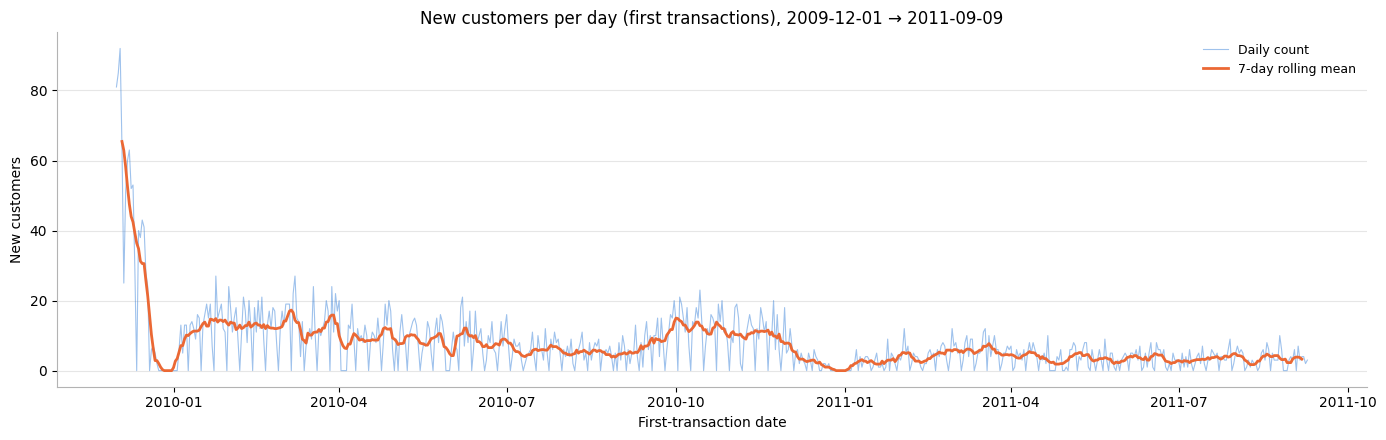


For reference, the same series by month:
               2009-12-31  2010-01-31  2010-02-28  2010-03-31  2010-04-30  2010-05-31  2010-06-30  2010-07-31  2010-08-31  2010-09-30  2010-10-31  2010-11-30  2010-12-31  2011-01-31  2011-02-28  2011-03-31  2011-04-30  2011-05-31  2011-06-30  2011-07-31  2011-08-31  2011-09-30
new_customers         889         343         349         413         279         250         259         183         156         234         369         313          76          70         123         178         105         108         108         101         106          32


In [8]:
first_dates = by_customer['invoice_date'].min().dt.normalize()

# Reindex across every calendar day so days with no new customers show as zero, not as a gap.
full_range = pd.date_range(first_dates.min(), first_dates.max(), freq='D')
daily = first_dates.value_counts().reindex(full_range, fill_value=0).sort_index()
rolling = daily.rolling(7, center=True).mean()

print(f'Date range           : {daily.index.min().date()} -> {daily.index.max().date()} '
      f'({len(daily):,} calendar days)')
print(f'Days with >=1 new customer : {(daily > 0).sum():,}')
print(f'Days with none             : {(daily == 0).sum():,}')
print(f'New customers per day      : min {daily.min()}, median {daily.median():.0f}, '
      f'mean {daily.mean():.1f}, max {daily.max()}')
print(f'Busiest day                : {daily.idxmax().date()} ({daily.max()} new customers)')

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily.index, daily.values, color=BLUE, lw=0.8, alpha=0.45, label='Daily count')
ax.plot(rolling.index, rolling.values, color=ORANGE, lw=2, label='7-day rolling mean')
ax.set_title('New customers per day (first transactions), 2009-12-01 → 2011-09-09')
ax.set_xlabel('First-transaction date')
ax.set_ylabel('New customers')
ax.legend(fontsize=9, frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

print('\nFor reference, the same series by month:')
print(daily.resample('ME').sum().to_frame('new_customers').T.to_string())

## 6. Churn rate over time (monthly)

The same time axis as §5, but showing the **outcome** rather than the arrival: of the customers who first bought in a given month, what share failed to return within 90 days?

Monthly rather than daily. At a median of 6 new customers per day, one customer moves a daily rate by ~17 points, so a daily churn line would be almost pure sampling noise. Months carry 32–889 customers each — still uneven, which is why the customer count is plotted directly beneath rather than squeezed onto a second y-axis.

**This is the chart that decides how you split the data.** If churn drifts materially across the period, a time-ordered train/validation/test split trains on one base rate and evaluates on another, and threshold-dependent metrics like F1 and precision/recall become miscalibrated. A stratified random split on `customer_id` holds the base rate constant instead. Read the swing here before choosing.

Two known artifacts are marked so they aren't read as trend:

- **The opening cohort.** The first 90 days (1,581 customers) churn at 36.1% against 50.0% afterwards — most likely established customers whose earlier history predates the file, appearing as new. See the §5 acquisition spike.
- **The closing edge.** `prepare_churn_data.py` already drops customers whose first purchase falls in the final 90 days, so the series simply ends at 2011-09-09 rather than tailing off into unlabelable months.

Churn rate by month of first purchase:
            customers  churn_rate
first_date                       
2009-12-01        889       33.30
2010-01-01        343       39.94
2010-02-01        349       39.26
2010-03-01        413       49.15
2010-04-01        279       51.97
2010-05-01        250       55.60
2010-06-01        259       50.19
2010-07-01        183       51.37
2010-08-01        156       39.74
2010-09-01        234       43.59
2010-10-01        369       51.22
2010-11-01        313       54.31
2010-12-01         76       72.37
2011-01-01         70       51.43
2011-02-01        123       56.91
2011-03-01        178       50.00
2011-04-01        105       56.19
2011-05-01        108       47.22
2011-06-01        108       43.52
2011-07-01        101       38.61
2011-08-01        106       39.62
2011-09-01         32       31.25

Overall churn rate  : 45.64%
Monthly range       : 31.2% (2011-09) to 72.4% (2010-12)
Swing               : 41.1%

Opening 90 days : 1,581 custo

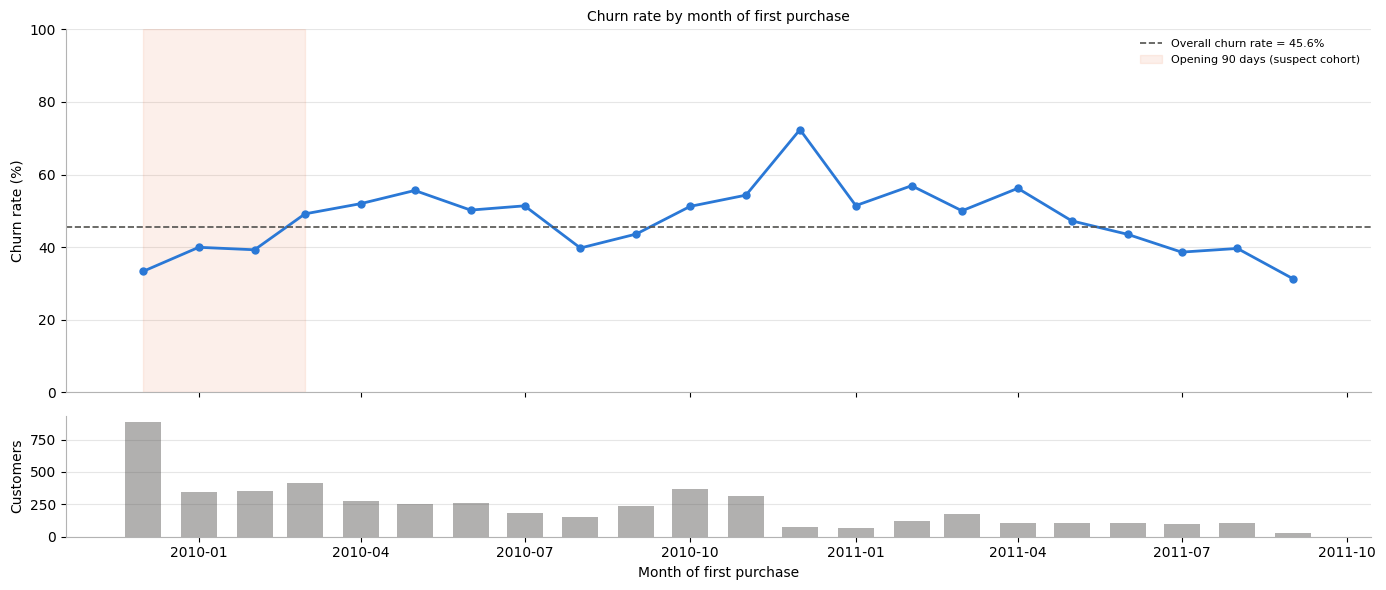

In [9]:
monthly = (customers.set_index('first_date')
           .resample('MS')['churn']
           .agg(customers='size', churn_rate='mean'))

print('Churn rate by month of first purchase:')
print(monthly.assign(churn_rate=lambda d: (d['churn_rate'] * 100).round(2)).to_string())
print()
print(f'Overall churn rate  : {churn_rate:.2%}')
print(f'Monthly range       : {monthly["churn_rate"].min():.1%} '
      f'({monthly["churn_rate"].idxmin():%Y-%m}) to {monthly["churn_rate"].max():.1%} '
      f'({monthly["churn_rate"].idxmax():%Y-%m})')
print(f'Swing               : {monthly["churn_rate"].max() - monthly["churn_rate"].min():.1%}')

opening = customers['first_date'] < customers['first_date'].min() + pd.Timedelta(days=90)
print(f'\nOpening 90 days : {opening.sum():,} customers, churn {customers.loc[opening, "churn"].mean():.1%}')
print(f'Everything after: {(~opening).sum():,} customers, churn {customers.loc[~opening, "churn"].mean():.1%}')

# Two stacked panels sharing the x-axis — never a second y-axis on the same plot.
fig, (ax_rate, ax_n) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

ax_rate.plot(monthly.index, monthly['churn_rate'] * 100, color=BLUE, lw=2, marker='o', ms=5)
ax_rate.axhline(churn_rate * 100, color=MUTED, ls='--', lw=1.2,
                label=f'Overall churn rate = {churn_rate:.1%}')
ax_rate.axvspan(monthly.index.min(), monthly.index.min() + pd.Timedelta(days=90),
                color=ORANGE, alpha=0.10, label='Opening 90 days (suspect cohort)')
ax_rate.set_title('Churn rate by month of first purchase', fontsize=10)
ax_rate.set_ylabel('Churn rate (%)')
ax_rate.set_ylim(0, 100)
ax_rate.legend(fontsize=8, frameon=False)
style_axis(ax_rate)

ax_n.bar(monthly.index, monthly['customers'], width=20, color=MUTED, alpha=0.45)
ax_n.set_ylabel('Customers')
ax_n.set_xlabel('Month of first purchase')
style_axis(ax_n)

plt.tight_layout()
plt.show()

## 7. Countries

One point to settle first: in this table **customers and transactions are the same count**. Each customer has exactly one invoice (§1), so "customers by country" and "transactions by country" are necessarily identical numbers. The table below therefore reports customers, line items and spend — three quantities that actually differ.

`01` §7 counts rows and customers by country across the full file. Here the customer counts are first-transaction customers only, and every country's figure is smaller.

The bar chart **excludes the United Kingdom**, which alone holds 4,613 of 5,044 customers (91.5%) and would compress every other country to invisibility. Its value is stated in the title rather than hidden.

Unique countries                  : 40
Countries with <10 customers      : 26
United Kingdom share of customers : 91.46%

Top 15 countries by first-transaction customers:
                 customers  line_items  total_spend  pct_customers  spend_per_customer
country                                                                               
United Kingdom        4613      112457 1,771,514.21          91.46              384.03
Germany                 87        2929    54,090.99           1.72              621.74
France                  70        1591    33,173.48           1.39              473.91
Spain                   29         731    14,324.10           0.57              493.93
Belgium                 25         641    12,556.93           0.50              502.28
Netherlands             22         428    12,711.24           0.44              577.78
Switzerland             19         796    28,827.09           0.38            1,517.22
Portugal                18         574     9,6

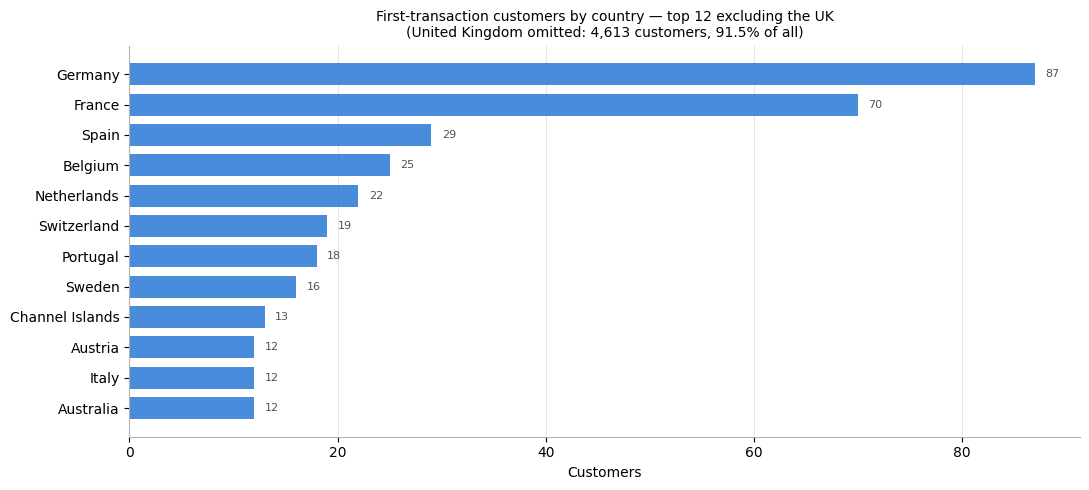

In [10]:
country_stats = (clean.groupby('country')
                 .agg(customers=('customer_id', 'nunique'),
                      line_items=('stock_code', 'size'),
                      total_spend=('line_total', 'sum'))
                 .sort_values('customers', ascending=False))
country_stats['pct_customers'] = (country_stats['customers'] / n_cust * 100).round(2)
country_stats['spend_per_customer'] = (country_stats['total_spend']
                                       / country_stats['customers']).round(2)

n_countries = clean['country'].nunique()
print(f'Unique countries                  : {n_countries}')
print(f'Countries with <10 customers      : {(country_stats["customers"] < 10).sum()}')
print(f'United Kingdom share of customers : {country_stats.loc["United Kingdom", "pct_customers"]:.2f}%')
print()
print('Top 15 countries by first-transaction customers:')
print(country_stats.head(15).to_string())

top_ex_uk = country_stats.drop('United Kingdom').head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_ex_uk.index, top_ex_uk['customers'], color=BLUE, alpha=0.85, height=0.72)
for name, value in zip(top_ex_uk.index, top_ex_uk['customers']):
    ax.text(value + 1, name, f'{value:,}', va='center', fontsize=8, color=MUTED)
uk = int(country_stats.loc['United Kingdom', 'customers'])
ax.set_title(f'First-transaction customers by country — top 12 excluding the UK\n'
             f'(United Kingdom omitted: {uk:,} customers, 91.5% of all)', fontsize=10)
ax.set_xlabel('Customers')
ax.grid(axis='x', color='0.9', lw=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('0.7')
plt.tight_layout()
plt.show()

### 7a. Average spend per customer by country

Charting the `spend_per_customer` column from the table above: total first-transaction spend divided by the country's customer count.

**Restricted to countries with more than 10 customers.** Without that filter the ranking is topped by Israel (2,691 GBP on 3 customers) and Thailand (1,957 GBP on 1) — means over one or two wholesale buyers, which say nothing about a country. The excluded countries are listed in the output along with how much of the dataset they represent.

The United Kingdom is kept here. It is not an outlier on this measure (384 GBP, below the overall average), so unlike the customer-count chart in §7 it doesn't compress the scale. Sample sizes are labelled on every bar and the dashed line is the overall average across all 5,044 customers.

Countries shown  : 13 of 40 (> 10 customers)
Countries dropped: 27, covering 96 customers (1.90% of the data)
Overall average spend per customer : 407.30 GBP

Average spend per customer:
                 customers  spend_per_customer
country                                       
Switzerland             19            1,517.22
Channel Islands         13              807.81
Austria                 12              639.33
Germany                 87              621.74
Italy                   12              581.65
Netherlands             22              577.78
Portugal                18              538.17
Belgium                 25              502.28
Spain                   29              493.93
Sweden                  16              493.78
France                  70              473.91
Australia               12              440.04
United Kingdom        4613              384.03


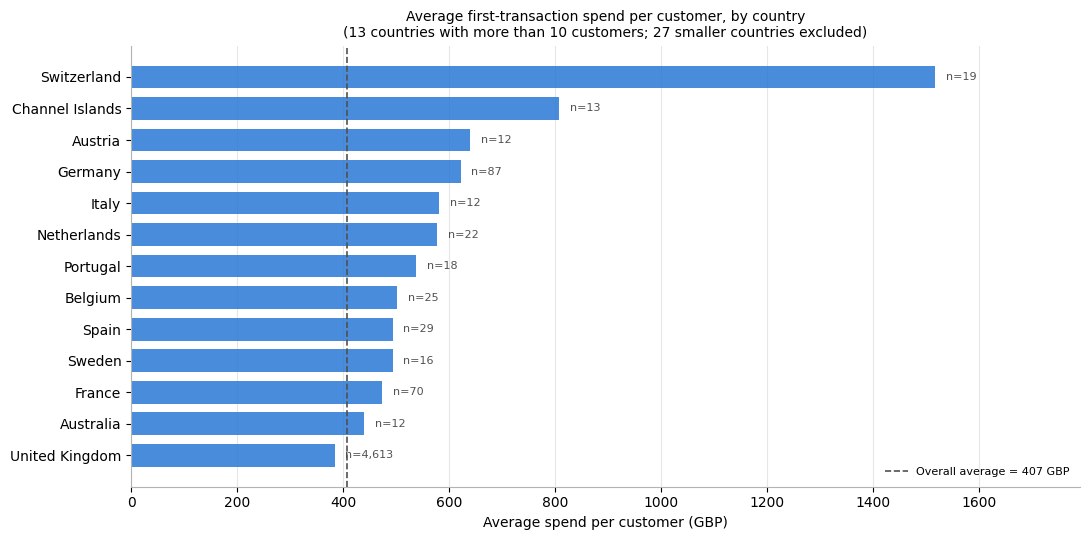

In [11]:
MIN_COUNTRY_CUSTOMERS = 10  # keep countries with MORE than this many customers

eligible = country_stats[country_stats['customers'] > MIN_COUNTRY_CUSTOMERS]
spend_by_country = eligible.sort_values('spend_per_customer', ascending=False)
overall_spend = customers['total_spend'].mean()

dropped = len(country_stats) - len(eligible)
dropped_customers = int(country_stats['customers'].sum() - eligible['customers'].sum())
print(f'Countries shown  : {len(eligible)} of {len(country_stats)} '
      f'(> {MIN_COUNTRY_CUSTOMERS} customers)')
print(f'Countries dropped: {dropped}, covering {dropped_customers} customers '
      f'({dropped_customers / n_cust * 100:.2f}% of the data)')
print(f'Overall average spend per customer : {overall_spend:,.2f} GBP')
print()
print('Average spend per customer:')
print(spend_by_country[['customers', 'spend_per_customer']].to_string())

ordered = spend_by_country.iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(ordered.index, ordered['spend_per_customer'], color=BLUE, alpha=0.85, height=0.72)
ax.axvline(overall_spend, color=MUTED, ls='--', lw=1.2,
           label=f'Overall average = {overall_spend:,.0f} GBP')
for name, row in ordered.iterrows():
    ax.text(row['spend_per_customer'] + 20, name, f'n={int(row["customers"]):,}',
            va='center', fontsize=8, color=MUTED)
ax.set_title(f'Average first-transaction spend per customer, by country\n'
             f'({len(eligible)} countries with more than {MIN_COUNTRY_CUSTOMERS} customers; '
             f'{dropped} smaller countries excluded)', fontsize=10)
ax.set_xlabel('Average spend per customer (GBP)')
ax.set_xlim(0, spend_by_country['spend_per_customer'].max() * 1.18)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.grid(axis='x', color='0.9', lw=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('0.7')
plt.tight_layout()
plt.show()

### 7b. Churn rate by country

**Same filter as 7a: countries with more than 10 customers.**

The filter matters more here than anywhere else in the notebook. Unfiltered, seven countries sit at exactly 100% churn and six at exactly 0% — every one of them on 1–3 customers, where those are the only values arithmetic allows. Ranking countries by such rates produces a chart that looks informative and is not.

Even after filtering, most surviving countries rest on 12–29 customers, so a 10-point difference between two of them is well inside sampling noise. The contrast worth trusting is the aggregate printed below the chart: **United Kingdom vs everywhere else**, at 4,613 against 431 customers. That is what an `is_uk` feature would capture, and it is far more defensible than a 40-level encoding fitted on counts this thin.

Countries shown: 13 (> 10 customers)

Churn rate by country:
                 customers  churn_rate
country                               
Spain                   29       51.72
Australia               12       50.00
Austria                 12       50.00
Sweden                  16       50.00
United Kingdom        4613       46.39
Netherlands             22       45.45
Belgium                 25       44.00
Italy                   12       41.67
France                  70       32.86
Germany                 87       28.74
Switzerland             19       21.05
Portugal                18       16.67
Channel Islands         13        7.69

Churn range across these countries: 7.7% to 51.7%

The comparison that holds:
  United Kingdom : 4,613 customers, churn 46.39%
  Everywhere else: 431 customers, churn 37.59%


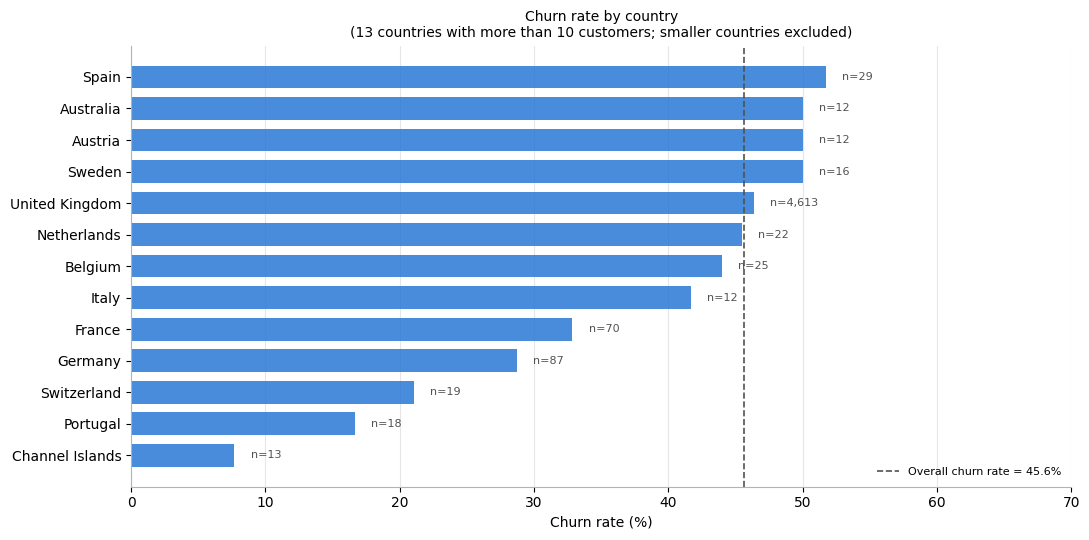

In [12]:
churn_by_country = (customers.groupby('country')['churn']
                    .agg(customers='size', churn_rate='mean'))
churn_by_country = (churn_by_country[churn_by_country['customers'] > MIN_COUNTRY_CUSTOMERS]
                    .sort_values('churn_rate', ascending=False))

print(f'Countries shown: {len(churn_by_country)} (> {MIN_COUNTRY_CUSTOMERS} customers)')
print()
print('Churn rate by country:')
print(churn_by_country.assign(
    churn_rate=lambda d: (d['churn_rate'] * 100).round(2)).to_string())
print(f'\nChurn range across these countries: '
      f'{churn_by_country["churn_rate"].min():.1%} to {churn_by_country["churn_rate"].max():.1%}')

is_uk = customers['country'] == 'United Kingdom'
print(f'\nThe comparison that holds:')
print(f'  United Kingdom : {is_uk.sum():,} customers, churn {customers.loc[is_uk, "churn"].mean():.2%}')
print(f'  Everywhere else: {(~is_uk).sum():,} customers, churn {customers.loc[~is_uk, "churn"].mean():.2%}')

ordered = churn_by_country.iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(ordered.index, ordered['churn_rate'] * 100, color=BLUE, alpha=0.85, height=0.72)
ax.axvline(churn_rate * 100, color=MUTED, ls='--', lw=1.2,
           label=f'Overall churn rate = {churn_rate:.1%}')
for name, row in ordered.iterrows():
    ax.text(row['churn_rate'] * 100 + 1.2, name, f'n={int(row["customers"]):,}',
            va='center', fontsize=8, color=MUTED)
ax.set_title(f'Churn rate by country\n'
             f'({len(churn_by_country)} countries with more than {MIN_COUNTRY_CUSTOMERS} '
             f'customers; smaller countries excluded)', fontsize=10)
ax.set_xlabel('Churn rate (%)')
ax.set_xlim(0, 70)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.grid(axis='x', color='0.9', lw=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('0.7')
plt.tight_layout()
plt.show()

## 8. Items

The first look at the data by **product** rather than by customer. Two questions:

- **8a** — how many `stock_code`s sell at more than one price, and how wide those price ranges are.
- **8b** — the average quantity purchased per `stock_code`.

Note the grain change: everything up to here has been one row per customer. These two cells group by `stock_code` instead, so a product bought by 500 customers contributes one row.

### 8a. Stock codes with more than one price

A single product appearing at several prices is normal in retail — discounts, wholesale tiers, price changes over the two-year window. But an extreme spread on one code can also mean the code is being reused for different things, which `stock_code`-as-source-of-truth would not catch.

**What `price_ratio` is.** For each stock code it is

```
price_ratio = max_price / min_price
```

— the dearest price that product ever sold at, divided by the cheapest. It answers *how many times over* the price moved, rather than by how many pounds.

A ratio is used instead of a subtraction because these products span 0.03 to 295.00 GBP. A 2.00 GBP swing is trivial on a 50 GBP item and enormous on a 0.10 GBP one, so an absolute gap would rank the expensive products top regardless of whether anything unusual happened. The ratio is scale-free and comparable across the whole catalogue.

Reading it:

- **`price_ratio = 1.0`** — the product only ever sold at one price.
- **`price_ratio = 1.26`** (the median among codes that vary) — the high price is 26% above the low. Ordinary discounting.
- **`price_ratio = 32.65`** (the maximum) — the same code sold at 0.17 and at 5.55. That is far past discounting and suggests the code was reused for a different product, or repriced wholesale.

The ratio is reported alongside the count so ordinary price movement and suspicious reuse can be told apart.

In [13]:
by_code = clean.groupby('stock_code')
items = pd.DataFrame({
    'n_lines': by_code.size(),
    'n_prices': by_code['price'].nunique(),
    'min_price': by_code['price'].min(),
    'max_price': by_code['price'].max(),
    'avg_quantity': by_code['quantity'].mean(),
})
items['price_ratio'] = items['max_price'] / items['min_price']

n_codes = len(items)
n_varying = int((items['n_prices'] > 1).sum())
print(f'Stock codes total            : {n_codes:,}')
print(f'With more than one price     : {n_varying:,} ({n_varying / n_codes * 100:.2f}%)')
print(f'With a single price          : {n_codes - n_varying:,} '
      f'({(n_codes - n_varying) / n_codes * 100:.2f}%)')
print()
print('Number of distinct prices per stock code:')
print(items['n_prices'].value_counts().sort_index().to_frame('stock_codes').to_string())

varying = items[items['n_prices'] > 1]
print()
print('Price spread (max / min) among the codes that vary:')
print(varying['price_ratio'].describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_string())
print()
print('Widest spreads — worth a look, a large ratio can mean the code is reused:')
print(varying.sort_values('price_ratio', ascending=False)
      .head(10)[['n_lines', 'n_prices', 'min_price', 'max_price', 'price_ratio']]
      .round(2).to_string())

Stock codes total            : 4,171
With more than one price     : 1,681 (40.30%)
With a single price          : 2,490 (59.70%)

Number of distinct prices per stock code:
          stock_codes
n_prices             
1                2490
2                1394
3                 227
4                  38
5                  22

Price spread (max / min) among the codes that vary:
count   1,681.00
mean        2.34
std         2.57
min         1.02
50%         1.26
90%         4.23
99%        13.40
max        32.65

Widest spreads — worth a look, a large ratio can mean the code is reused:
            n_lines  n_prices  min_price  max_price  price_ratio
stock_code                                                      
16202A            2         2       0.17       5.55        32.65
16202B            4         3       0.17       5.55        32.65
84927E            4         2       0.08       2.10        26.25
84927D            5         3       0.08       2.10        26.25
84927A            3 

### 8b. Average quantity purchased per stock code

For each `stock_code`, the mean `quantity` across every line it appears on — the typical order size for that product.

**Log x-axis, nothing excluded.** The range runs from 1 to over 1,000 units with a median near 6, so on a linear scale the entire distribution would pile into the first bin. Bin edges are spaced logarithmically, which makes the shape readable across all three orders of magnitude. Bar heights are still plain counts of stock codes.

Average quantity purchased per stock code:
count   4,171.00
mean       12.49
std        43.81
min         1.00
25%         2.90
50%         5.84
75%        10.62
90%        19.25
99%       133.08
max     1,056.40

Stock codes averaging 1 unit per line : 194 (4.65%)
Stock codes averaging >= 100 units    : 56 (1.34%)

Highest average order size:
            n_lines  avg_quantity  min_price  max_price
stock_code                                             
16047             5      1,056.40       0.08       0.85
16053             2      1,025.00       0.03       0.21
16162L            5        785.00       0.05       0.65
85110             8        704.75       0.07       0.85
37471             1        684.00       0.10       0.10
84493             1        567.00       0.08       0.08
84760L            1        560.00       1.60       1.60
85160A            8        547.00       0.13       1.25
16014            13        480.54       0.32       0.42
84924F            1        480.00     

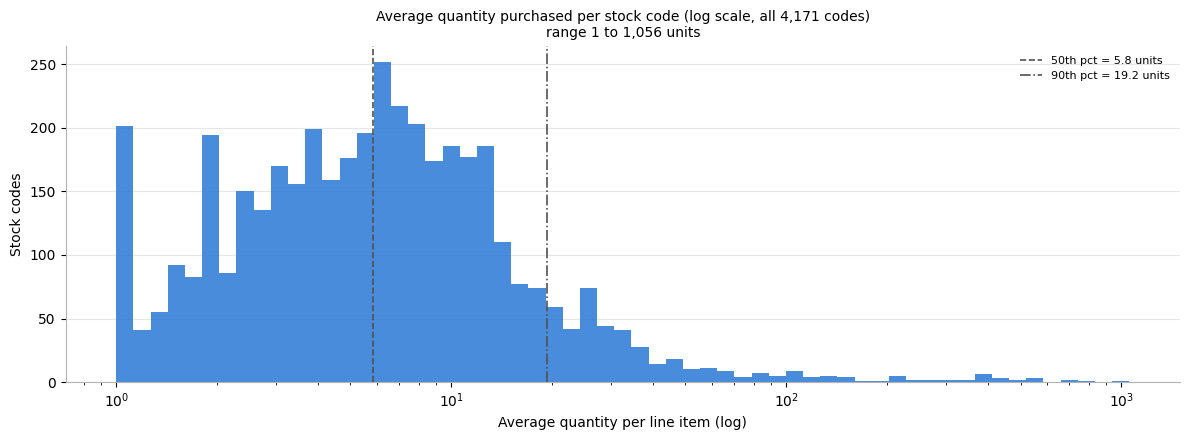

In [14]:
avg_qty = items['avg_quantity']

print('Average quantity purchased per stock code:')
print(avg_qty.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2).to_string())
print()
print(f'Stock codes averaging 1 unit per line : {(avg_qty == 1).sum():,} '
      f'({(avg_qty == 1).mean()*100:.2f}%)')
print(f'Stock codes averaging >= 100 units    : {(avg_qty >= 100).sum():,} '
      f'({(avg_qty >= 100).mean()*100:.2f}%)')
print()
print('Highest average order size:')
print(items.sort_values('avg_quantity', ascending=False)
      .head(10)[['n_lines', 'avg_quantity', 'min_price', 'max_price']].round(2).to_string())

# Logarithmic bin edges so the shape is readable across three orders of magnitude.
bins = np.logspace(np.log10(avg_qty.min()), np.log10(avg_qty.max()), 60)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(avg_qty, bins=bins, color=BLUE, alpha=0.85)
for p, ls in [(0.5, '--'), (0.9, '-.')]:
    v = avg_qty.quantile(p)
    ax.axvline(v, color=MUTED, ls=ls, lw=1.2, label=f'{int(p*100)}th pct = {v:,.1f} units')
ax.set_xscale('log')
ax.set_title(f'Average quantity purchased per stock code (log scale, all {len(items):,} codes)\n'
             f'range {avg_qty.min():,.0f} to {avg_qty.max():,.0f} units', fontsize=10)
ax.set_xlabel('Average quantity per line item (log)')
ax.set_ylabel('Stock codes')
ax.legend(fontsize=8, frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()